## Import Liberaries

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import tensorflow
from tensorflow import keras
from keras.layers import Input, Conv2D
# from keras import Sequential
# from keras.layers import Input, Flatten, Conv2D, Dense, MaxPool2D
from keras.models import Model

In [2]:
import os
import tensorflow as tf
import tifffile as tiff
from glob import glob

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Model Architecture

In [4]:
def build_srcnn(input_shape=(None, None, 3)):
    """
    Builds a 3-layer SRCNN model.

    Parameters:
        input_shape (tuple): Shape of input image (H, W, C)

    Returns:
        model (tf.keras.Model): SRCNN model
    """

    inputs = Input(shape=input_shape)

    # Layer 1: Patch extraction
    x = Conv2D(
        filters=64,
        kernel_size=(9, 9),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv1'
    )(inputs)

    # Layer 2: Non-linear mapping
    x = Conv2D(
        filters=32,
        kernel_size=(5, 5),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv2'
    )(x)

    # Layer 3: Reconstruction
    outputs = Conv2D(
        filters=3,
        kernel_size=(5, 5),
        strides=(1, 1),
        padding='same',
        activation='linear',
        name='conv3'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='SRCNN')

    return model

In [24]:
# model2=Sequential([
#     Input(shape=(None, None, 3)),
#     Conv2D(64, (9, 9), padding='same', activation='relu'), # default value of stride=(1,1)
#     Conv2D(32, (5, 5), padding='same', activation='relu'),
#     Conv2D(3, (5, 5), padding='same', activation='linear')
# ])
# model2.summary()

In [5]:
# Create the model
model = build_srcnn(input_shape=(None, None,3))

# Display model summary
model.summary()

I0000 00:00:1786433894.549852      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786433894.552650      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, None, None, 64) │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, None, None, 32) │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, None, None, 3)  │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,251 (270.51 KB)

 Trainable params: 69,251 (270.51 KB)

 Non-trainable params: 0 (0.00 B)

## Creating data pipeline

In [7]:
TRAIN_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/HR_0.5m"
TRAIN_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/LR_1m"

VAL_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/HR_0.5m"
VAL_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/LR_1m"

TEST_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/HR_0.5m"
TEST_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/LR_1m"

- now every 6th patch is irrespective to any resolution is smaller in size
  > format (H, W, C) I don't know why this happen
    - for HR ideal: (512, 512, 3), (n+6)th patch: (512, 440, 3)
    - for LR_1m ideal: (256, 256, 3), (n+6)th patch: (256, 220, 3)
    - for LR_2m ideal: (128, 128, 3), (n+6)th patch: (128, 110, 3)

- I have 2 solutions:
    - Filter the bad/edge patches, in get_image_pairs()`
        - SRCNN is fully convolutional model, so it can process images of any size at inference
    - Add padding to the edge patches, inside `preprocess()`
```
lr = tf.image.resize_with_crop_or_pad(lr, 256, 256)
hr = tf.image.resize_with_crop_or_pad(hr, 512, 512)
```
- for now I choose to filter the edge patches

In [8]:
def get_image_pairs(hr_root, lr_root):

    hr_paths = sorted(glob(os.path.join(hr_root, "*", "*.tif")))
    lr_paths = sorted(glob(os.path.join(lr_root, "*", "*.tif")))
    # assert len(hr_paths) == len(lr_paths), "HR and LR image count mismatch!"
    # return hr_paths, lr_paths
    
    good_hr = []
    good_lr = []

    for hr, lr in zip(hr_paths, lr_paths):

        hr_img = tiff.imread(hr)
        lr_img = tiff.imread(lr)

        if hr_img.shape == (512,512,3) and lr_img.shape == (256,256,3):
            good_hr.append(hr)
            good_lr.append(lr)

    return good_hr, good_lr

In [9]:
train_hr, train_lr = get_image_pairs(TRAIN_HR, TRAIN_LR)
val_hr, val_lr = get_image_pairs(VAL_HR, VAL_LR)

print("Training patches :", len(train_hr))
print("Validation patches :", len(val_hr))

Training patches : 4375
Validation patches : 925


In [10]:
# import tifffile as tiff
sample = tiff.imread(train_hr[0])

print(sample.dtype)
print(sample.min(), sample.max())

uint8
0 240


In [11]:
def load_image(lr_path, hr_path):

    lr = tiff.imread(lr_path.decode())

    hr = tiff.imread(hr_path.decode())

    return lr.astype(np.float32), hr.astype(np.float32)

In [12]:
def preprocess(lr_path, hr_path):
# uses tf.numpy_function to wrap a regular Python/NumPy function (load_image) 
# so it can be used inside a TensorFlow data pipeline
    lr, hr = tf.numpy_function(
        load_image,
        [lr_path, hr_path],
        [tf.float32, tf.float32]
    )

    lr.set_shape([256,256,3])
    hr.set_shape([512,512,3])

    # Bicubic Upsampling
    lr = tf.image.resize(
        lr,
        [512,512],
        method='bicubic'
    )

    # Normalize

    lr = lr / 255.0
    hr = hr / 255.0

    return lr, hr

## Defining TensorFlow dataset
- dataset: (lr_image, hr_image)

In [14]:
# BATCH_SIZE = 16
BATCH_SIZE = 8
# BATCH_SIZE = 4
# BATCH_SIZE = 2

AUTOTUNE = tf.data.AUTOTUNE


train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_lr, train_hr)
)

train_dataset = (
    train_dataset
    .shuffle(1000)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_lr, val_hr)
)

val_dataset = (
    val_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [15]:
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(
#         learning_rate=1e-4
#     ),
#     loss='mse',
#     metrics=['mae']
# )

# Uses both the GPUs
strategy = tf.distribute.MirroredStrategy()

print("Number of devices:", strategy.num_replicas_in_sync)

with strategy.scope():
    model = build_srcnn()      # your model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=['mae']
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


- Here's all the internal working
    - TensorFlow detects both GPUs
    - A **copy of the model** is created on each GPU. Initially, both copies have identical weights.
    - The **batch is split** automatically
        - If batch=32, it splits into 16, 16. Each GPU performs the forward and backward pass on its own portion of the batch.
    - After computing gradients: TensorFlow uses an efficient communication method (such as NCCL on NVIDIA GPUs) to **average the gradients**, applies a single optimizer update, and then keeps the model weights synchronized across both GPUs.

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_srcnn.keras",
    monitor="val_loss",
    save_best_only=True
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    # patience=10,
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    # patience=5
    patience=3
)

In [42]:
# for lr_path in train_lr[:20]:
#     img = tiff.imread(lr_path)
#     print(img.shape)

## Model training

In [17]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint,
               earlystop,
               reduce_lr]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [18]:
model.save("SRCNN_Final.keras")

## After stopping training

In [19]:
test_hr, test_lr = get_image_pairs(TEST_HR, TEST_LR)

In [20]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_lr, test_hr)
)

test_dataset = (
    test_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [21]:
lr, hr = next(iter(test_dataset))

# Bicubic baseline
bicubic = tf.image.resize(lr, [512, 512], method="bicubic")

# SRCNN prediction
sr = model.predict(bicubic, verbose=0)

# PSNR
bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
srcnn_psnr = tf.image.psnr(hr, sr, max_val=1.0)

print("Bicubic PSNR:", bicubic_psnr.numpy().mean())
print("SRCNN PSNR :", srcnn_psnr.numpy().mean())

Bicubic PSNR: 24.800682
SRCNN PSNR : 26.05004


In [53]:
def plot_image(org_img, bicubic_img, sr_img):
    # Convert TensorFlow tensor to NumPy
    if tf.is_tensor(org_img):
        org_img = org_img.numpy()

    if tf.is_tensor(bicubic_img):
        bicubic_img = bicubic_img.numpy()

    # Remove batch dimension if present
    org_img = np.squeeze(org_img)
    bicubic_img = np.squeeze(bicubic_img)
    sr_img = np.squeeze(sr_img)

    # Convert CHW -> HWC if necessary
    if org_img.ndim == 3 and org_img.shape[0] in [1, 3]:
        org_img = org_img.transpose(1, 2, 0)

    if bicubic_img.ndim == 3 and bicubic_img.shape[0] in [1, 3]:
        bicubic_img = bicubic_img.transpose(1, 2, 0)

    if sr_img.ndim == 3 and sr_img.shape[0] in [1, 3]:
        sr_img = sr_img.transpose(1, 2, 0)

    # Keep values in the normalized [0, 1] range
    org_img = np.clip(org_img, 0, 1)
    bicubic_img = np.clip(bicubic_img, 0, 1)
    sr_img = np.clip(sr_img, 0, 1)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(org_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(bicubic_img)
    plt.title("Bicubic Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sr_img)
    plt.title("SRCNN Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [48]:
h=hr[0].numpy()
h.max()

np.float32(1.0)

In [45]:
b=bicubic[0].numpy()
b.max()

np.float32(0.8189803)

In [46]:
sr[0].max()

np.float32(1.0183555)

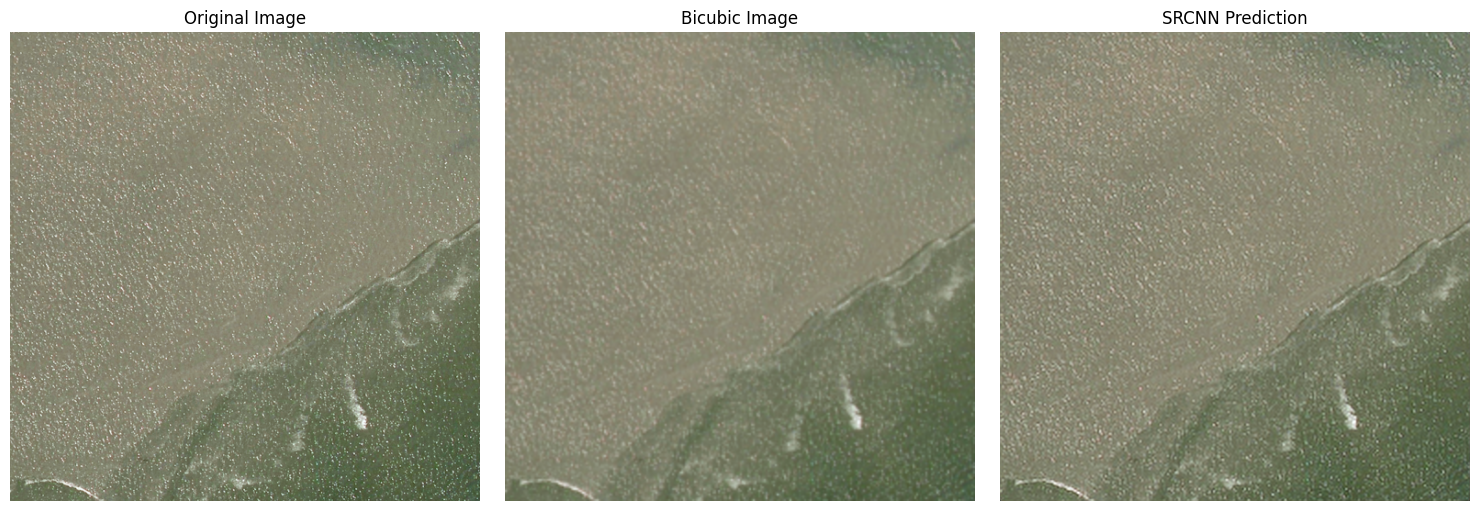

In [61]:
plot_image(hr[7],
           bicubic[7],
           sr[7])

In [62]:
hr.shape

TensorShape([8, 512, 512, 3])